In [2]:
import pandas as pd
from torchvision import transforms as T
from torch.utils.data import DataLoader
from circuit_toolkit.dataset_utils import ImagePathDataset

subject_id = "venus_250426-250429"
csv_path = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}/posthoc_model_predict/accentuated_stim_info_{subject_id}.csv"

# 1. Load CSV with filepaths
df_acc = pd.read_csv(csv_path)
img_paths = df_acc["filepath"].tolist()  # absolute PNG paths like ...Accentuate_VVS/accentuation_outputs/...png

# 2. Define transform (match your model’s preprocessing if needed)
tfm = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    # add Normalize(...) here to match model if you’re feeding into a network
])

# 3. Wrap in a dataset + dataloader
dataset = ImagePathDataset(img_paths, transform=tfm)
loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=4)

# 4. Iterate and get image tensors
for imgs in loader:
    # imgs is a batch of image tensors (B, C, H, W)
    # do whatever you want here (e.g., feed to model, visualize, etc.)
    pass

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


The (227, 227) setting is overwritten by the size in custom transform


In [52]:
from PIL import Image
import numpy as np

def path_to_nparray(img_path, resolution=None):
    """
    Load an image from path using PIL and return as numpy array (H, W, C) in float32, range 0-1.

    Args:
        img_path (str): Path to image file.
        resolution (tuple or None): Optional, (H, W) to resize image before converting to array.

    Returns:
        arr (np.ndarray): Image as numpy array (H, W, C), dtype=float32, values in [0, 1].
    """
    img = Image.open(img_path).convert("RGB")
    if resolution is not None:
        img = img.resize(resolution[::-1], Image.BILINEAR)  # PIL uses (W, H)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr

In [6]:
df_acc

,Unnamed: 0,model_name,unit_id,img_id,level,score,filepath
0,0,AlexNet_training_seed_01,151,0,-0.340731,-0.331229,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
1,1,AlexNet_training_seed_01,151,0,-0.764533,-0.754743,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
2,2,AlexNet_training_seed_01,151,0,-1.188334,-1.178634,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
3,3,AlexNet_training_seed_01,151,0,-1.612136,-1.602639,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
4,4,AlexNet_training_seed_01,151,0,0.083071,0.092235,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
...,...,...,...,...,...,...,...
5495,5495,siglip2_vitb16,9,9,1.062953,1.053078,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
5496,5496,siglip2_vitb16,9,9,1.557169,1.547310,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
5497,5497,siglip2_vitb16,9,9,2.051386,1.922004,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
5498,5498,siglip2_vitb16,9,9,2.545602,1.847999,/n/holylabs/LABS/alvarez_lab/Everyone/Accentua...


In [11]:
subject_id = "venus_250426-250429"
for subject_id in ['leap_250426-250501', 'paul_20250428-20250430',
                     'red_20250428-20250430', 'three0_250426-250501',
                     'venus_250426-250429']:
    csv_path = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}/posthoc_model_predict/accentuated_stim_info_{subject_id}.csv"
    df = pd.read_csv(csv_path)
    img_paths = df_acc["filepath"].tolist()  # absolute PNG paths like ...Accentuate_VVS/accentuation_outputs/...png

In [73]:
import numpy as np

def image_fourier_power(img, return_shifted_spectrum=False):
    """
    Compute the 2D Fourier power spectrum of an image.
    Args:
        img (np.ndarray): 2D grayscale (H, W) or RGB (H, W, 3) image as ndarray.
        return_shifted_spectrum (bool): If True, also return shifted (centered) spectrum.
    Returns:
        power (np.ndarray): 2D power spectrum (H, W)
        (optionally) shifted_spectrum (np.ndarray): Shifted (centered) power spectrum
    """
    # If RGB, convert to grayscale
    if img.ndim == 3:
        img_gray = np.mean(img, axis=2)
    else:
        img_gray = img
    img_gray = img_gray.astype(np.float32)
    F = np.fft.fft2(img_gray)
    F_shift = np.fft.fftshift(F)  # center low-freq at center
    power = np.abs(F) ** 2
    power_shift = np.abs(F_shift) ** 2
    if return_shifted_spectrum:
        return power, power_shift
    return power


def fourier_power_radial_profile(power):
    """
    Compute the radial (frequency) average of a 2D power spectrum.
    Args:
        power (np.ndarray): 2D power spectrum (H, W)
    Returns:
        radial_prof (np.ndarray): 1D radial profile (mean power at each radius)
    """
    y, x = np.indices(power.shape)
    center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
    r = np.hypot(x - center[0], y - center[1])
    # Bin the radii
    r = r.astype(np.int32)
    # Compute mean for each radius
    radial_prof = np.bincount(r.ravel(), power.ravel()) / np.bincount(r.ravel())
    return radial_prof


def fourier_power_radial_profile_with_counts(power):
    """
    Compute the radial (frequency) average of a 2D power spectrum.
    Args:
        power (np.ndarray): 2D power spectrum (H, W)
    Returns:
        radial_prof (np.ndarray): 1D radial profile (mean power at each radius)
        bincounts (np.ndarray): 1D array, the count of pixels in each radius bin
    """
    y, x = np.indices(power.shape)
    center = np.array([(x.max() - x.min()) / 2.0, (y.max() - y.min()) / 2.0])
    r = np.hypot(x - center[0], y - center[1])
    # Bin the radii
    r_int = r.astype(np.int32)
    # Compute mean for each radius, and also pixel count per radius bin
    bincounts = np.bincount(r_int.ravel())
    radial_prof = np.bincount(r_int.ravel(), power.ravel()) / bincounts
    return radial_prof, bincounts

def image_fourier_power_diff(img1, img2):
    """
    Compute the difference in Fourier power spectrum between two images.
    Returns the absolute and signed difference.
    Args:
        img1, img2 (np.ndarray): Two images, same shape.
    Returns:
        diff_abs (np.ndarray): Absolute difference (same shape as input)
        diff_signed (np.ndarray): Signed difference (img1 - img2)
    """
    pow1 = image_fourier_power(img1)
    pow2 = image_fourier_power(img2)
    diff_signed = pow1 - pow2
    diff_abs = np.abs(diff_signed)
    return diff_abs, diff_signed

# Example usage:
# img = path_to_nparray(img_path)
# power, power_shift = image_fourier_power(img, return_shifted_spectrum=True)
# prof = fourier_power_radial_profile(power_shift)

In [19]:
# subject_id = "venus_250426-250429"
# for subject_id in ['leap_250426-250501', 'paul_20250428-20250430',
#                      'red_20250428-20250430', 'three0_250426-250501',
#                      'venus_250426-250429']:
subject_id = 'red_20250428-20250430'
csv_path = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}/posthoc_model_predict/accentuated_stim_info_{subject_id}.csv"
df_acc = pd.read_csv(csv_path, index_col=0)
img_paths = df_acc["filepath"].tolist()  # absolute PNG paths like ...Accentuate_VVS/accentuation_outputs/...png

In [20]:
model_name = "resnet50_robust"
df_acc_part = df_acc.query("unit_id == 0 and img_id == 0 and model_name == @model_name")

In [22]:
# Find the rows with max and min 'level'
row_max_level = df_acc_part.loc[df_acc_part['level'].idxmax()]
row_min_level = df_acc_part.loc[df_acc_part['level'].idxmin()]
display(row_max_level)
display(row_min_level)

model_name                                      resnet50_robust
unit_id                                                       0
img_id                                                        0
level                                                  6.244637
score                                                  4.022564
filepath      /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
Name: 4410, dtype: object

model_name                                      resnet50_robust
unit_id                                                       0
img_id                                                        0
level                                                 -1.846455
score                                                 -1.836622
filepath      /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...
Name: 4402, dtype: object

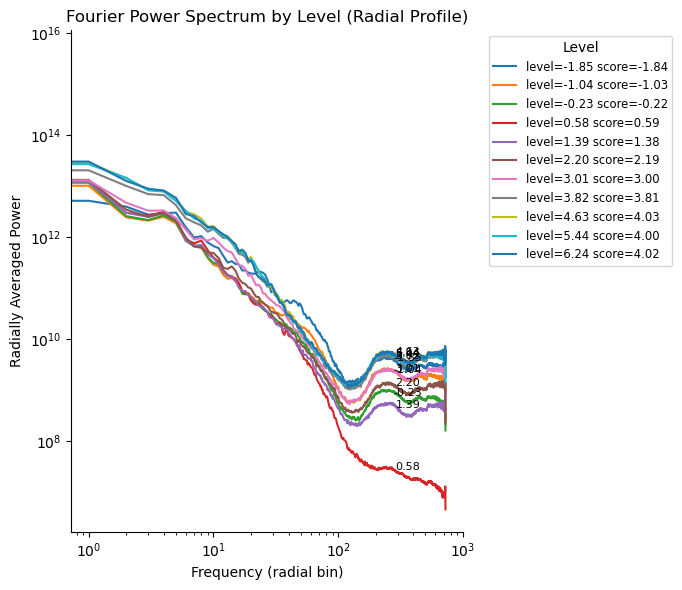

In [31]:
import matplotlib.pyplot as plt
# Sort df_acc_part by level
df_sorted = df_acc_part.sort_values(by="level")
levels_sorted = df_sorted['level'].values
scores_sorted = df_sorted['score'].values
filepaths_sorted = df_sorted['filepath'].values

spectra_profiles = []
for path in filepaths_sorted:
    arr = path_to_nparray(path)
    _, power_shift = image_fourier_power(arr, return_shifted_spectrum=True)
    profile = fourier_power_radial_profile(power_shift)
    spectra_profiles.append(profile)
spectra_profiles = np.stack(spectra_profiles, axis=0)
freqs = np.arange(spectra_profiles.shape[1])

plt.figure(figsize=(7, 6))
for i, (level, prof) in enumerate(zip(levels_sorted, spectra_profiles)):
    # Plot
    plt.plot(freqs, prof, label=f"level={level:.2f} score={scores_sorted[i]:.2f}")
    # Annotate only at a mid-frequency as example
    mid_bin = len(freqs) // 2
    plt.annotate(f"{level:.2f}", 
                 (freqs[mid_bin], prof[mid_bin]), 
                 textcoords="offset points", 
                 xytext=(0, 5), ha='center', fontsize=8)

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Frequency (radial bin)')
plt.ylabel('Radially Averaged Power')
plt.title('Fourier Power Spectrum by Level (Radial Profile)')
plt.legend(title="Level", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize='small')
plt.tight_layout()
plt.show()


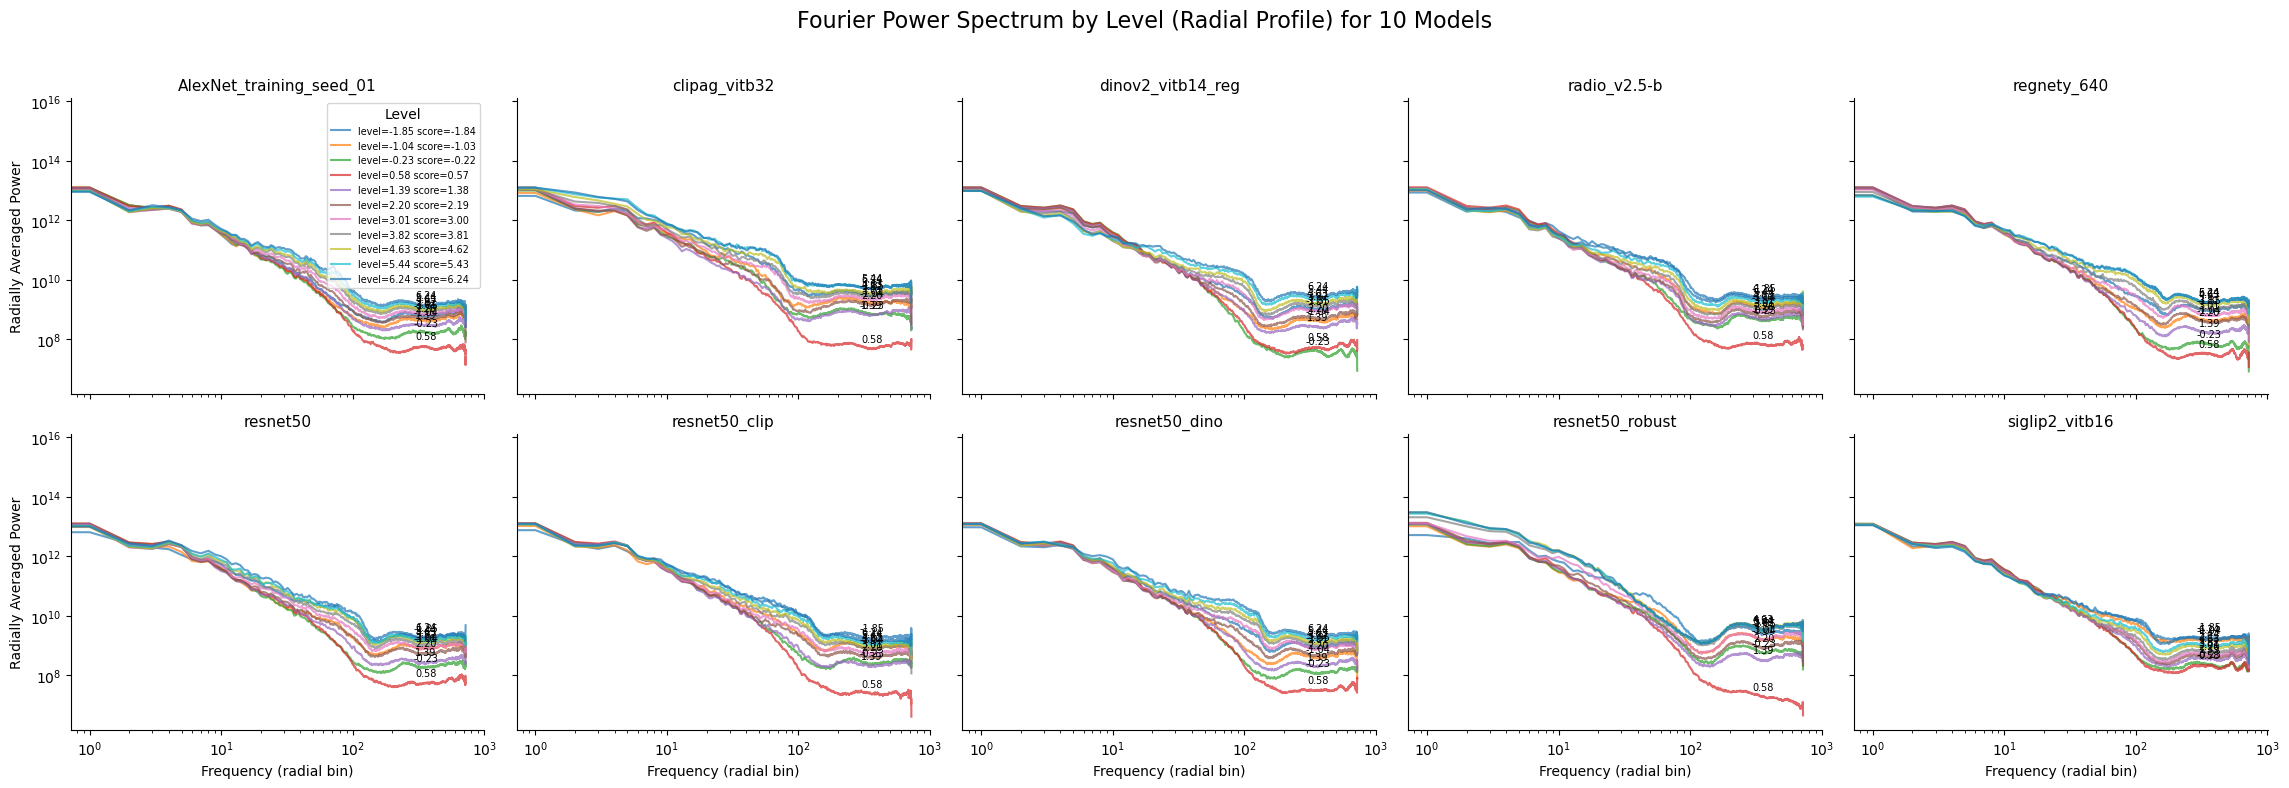

In [34]:
import matplotlib.pyplot as plt

# Choose 10 unique model names (make sure df_acc contains at least 10, otherwise adjust)
model_names = df_acc["model_name"].unique()[:10]
fig, axes = plt.subplots(2, 5, figsize=(23, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_names):
    df_acc_part = df_acc.query("unit_id == 0 and img_id == 0 and model_name == @model_name")
    # Sort by level
    df_sorted = df_acc_part.sort_values(by="level")
    levels_sorted = df_sorted['level'].values
    scores_sorted = df_sorted['score'].values
    filepaths_sorted = df_sorted['filepath'].values

    spectra_profiles = []
    for path in filepaths_sorted:
        arr = path_to_nparray(path)
        _, power_shift = image_fourier_power(arr, return_shifted_spectrum=True)
        profile = fourier_power_radial_profile(power_shift)
        spectra_profiles.append(profile)
    spectra_profiles = np.stack(spectra_profiles, axis=0)
    freqs = np.arange(spectra_profiles.shape[1])

    for i, (level, prof) in enumerate(zip(levels_sorted, spectra_profiles)):
        ax.plot(freqs, prof, label=f"level={level:.2f} score={scores_sorted[i]:.2f}", alpha=0.7)
        mid_bin = len(freqs) // 2
        ax.annotate(f"{level:.2f}",
                    (freqs[mid_bin], prof[mid_bin]),
                    textcoords="offset points",
                    xytext=(0, 5), ha='center', fontsize=7)
    ax.set_title(f"{model_name}", fontsize=11)
    ax.set_yscale('log')
    ax.set_xscale('log')
    # Matplotlib does not provide is_last_row or is_first_col for Axes, so we must check by index
    idx = np.where(axes == ax)[0][0]
    nrows, ncols = 2, 5
    row = idx // ncols
    col = idx % ncols
    if row == nrows - 1:
        ax.set_xlabel('Frequency (radial bin)')
    if col == 0:
        ax.set_ylabel('Radially Averaged Power')
    # Only show legend for the first axis (can also omit to save space)
    if ax == axes[0]:
        ax.legend(title="Level", fontsize='x-small', loc='upper right')

fig.suptitle('Fourier Power Spectrum by Level (Radial Profile) for 10 Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


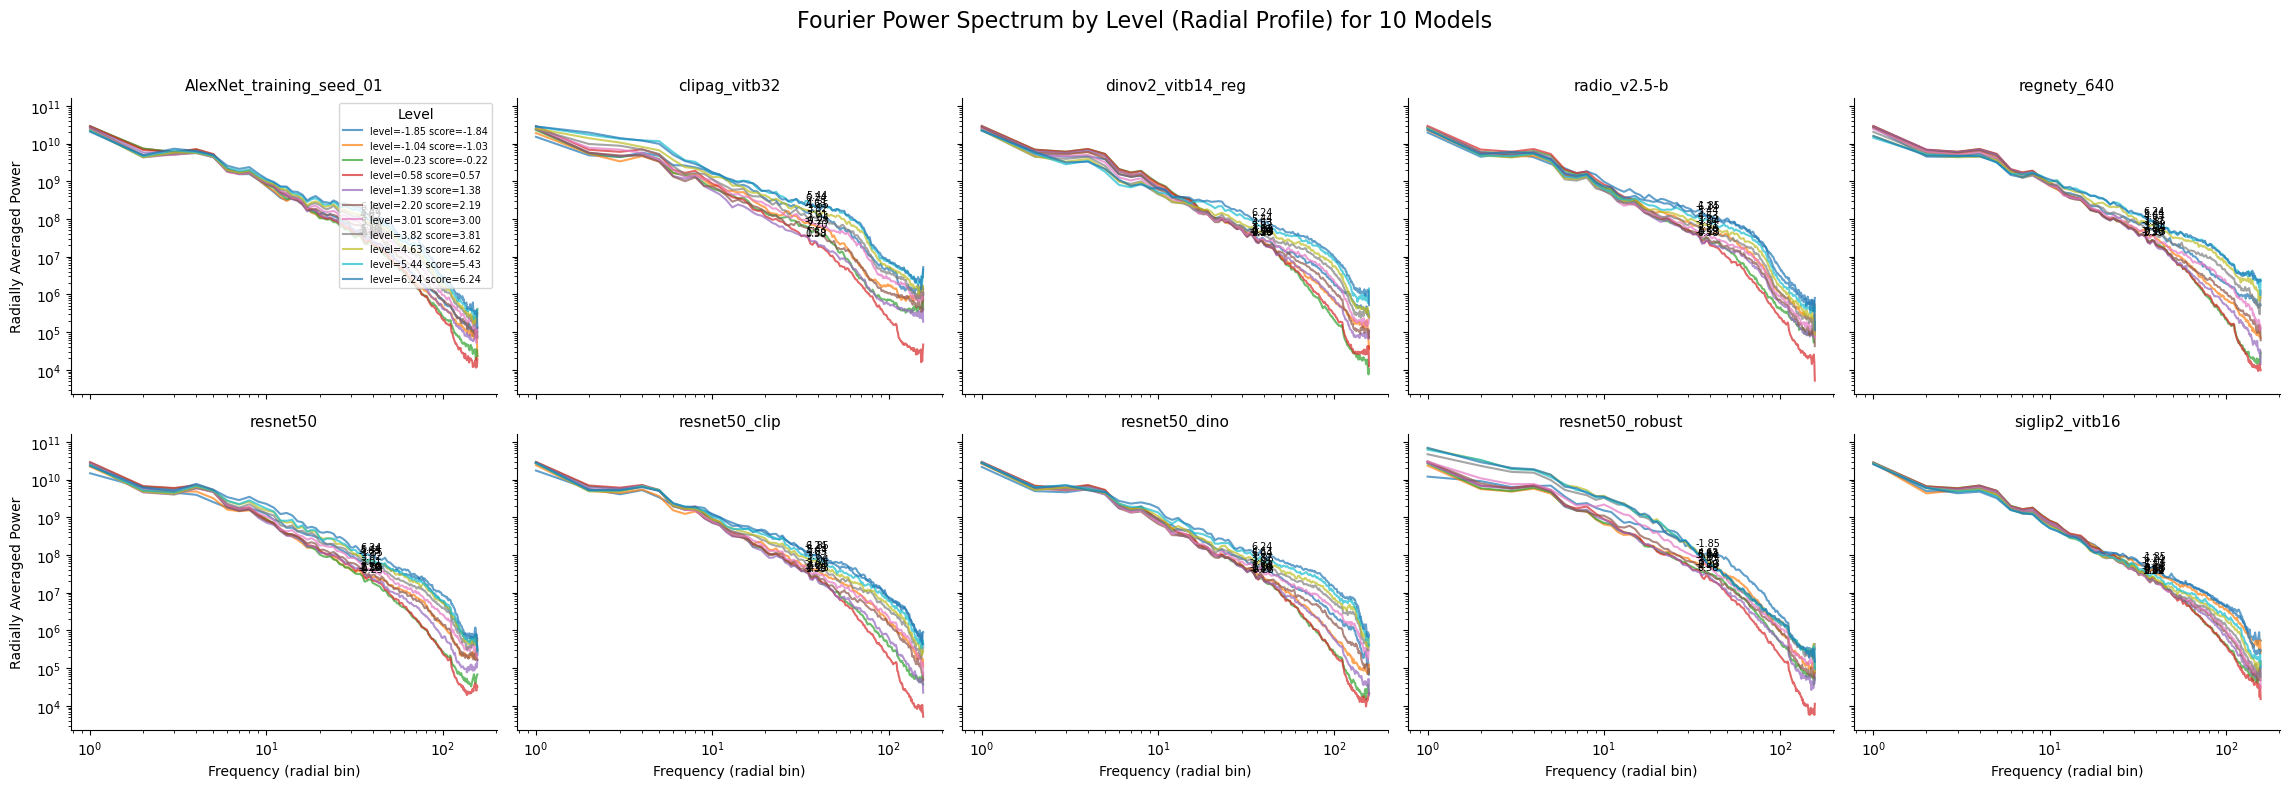

In [37]:
import matplotlib.pyplot as plt

# Choose 10 unique model names (make sure df_acc contains at least 10, otherwise adjust)
model_names = df_acc["model_name"].unique()[:10]
fig, axes = plt.subplots(2, 5, figsize=(23, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_names):
    df_acc_part = df_acc.query("unit_id == 0 and img_id == 0 and model_name == @model_name")
    # Sort by level
    df_sorted = df_acc_part.sort_values(by="level")
    levels_sorted = df_sorted['level'].values
    scores_sorted = df_sorted['score'].values
    filepaths_sorted = df_sorted['filepath'].values

    spectra_profiles = []
    for path in filepaths_sorted:
        arr = path_to_nparray(path, resolution=(224, 224))
        _, power_shift = image_fourier_power(arr, return_shifted_spectrum=True)
        profile = fourier_power_radial_profile(power_shift)
        spectra_profiles.append(profile)
    spectra_profiles = np.stack(spectra_profiles, axis=0)
    freqs = np.arange(spectra_profiles.shape[1])

    for i, (level, prof) in enumerate(zip(levels_sorted, spectra_profiles)):
        ax.plot(freqs[freqs>0], prof[freqs>0], label=f"level={level:.2f} score={scores_sorted[i]:.2f}", alpha=0.7)
        mid_bin = len(freqs) // 4
        ax.annotate(f"{level:.2f}",
                    (freqs[mid_bin], prof[mid_bin]),
                    textcoords="offset points",
                    xytext=(0, 5), ha='center', fontsize=7)
    ax.set_title(f"{model_name}", fontsize=11)
    ax.set_yscale('log')
    ax.set_xscale('log')
    # Matplotlib does not provide is_last_row or is_first_col for Axes, so we must check by index
    idx = np.where(axes == ax)[0][0]
    nrows, ncols = 2, 5
    row = idx // ncols
    col = idx % ncols
    if row == nrows - 1:
        ax.set_xlabel('Frequency (radial bin)')
    if col == 0:
        ax.set_ylabel('Radially Averaged Power')
    # Only show legend for the first axis (can also omit to save space)
    if ax == axes[0]:
        ax.legend(title="Level", fontsize='x-small', loc='upper right')

fig.suptitle('Fourier Power Spectrum by Level (Radial Profile) for 10 Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [62]:
seed_image_paths = [
    "shared1000/shared0575_nsd43157.png",
    "shared1000/shared0850_nsd61798.png",
    "shared1000/shared0968_nsd70194.png",
    "shared1000/shared0241_nsd20065.png",
    "shared1000/shared0160_nsd13231.png",
    "shared1000/shared0070_nsd07008.png",
    "shared1000/shared0055_nsd05879.png",
    "shared1000/shared0668_nsd48623.png",
    "shared1000/shared0488_nsd36979.png",
    "shared1000/shared0940_nsd68312.png"
]

# Load the seed images and collect them into a list of numpy arrays
from os.path import join
shared_dir = "/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Stimuli/"
seed_images_np = [path_to_nparray(join(shared_dir, path), resolution=(224, 224)) for path in seed_image_paths]

In [46]:
seed_images_np[0].shape

(425, 425, 3)

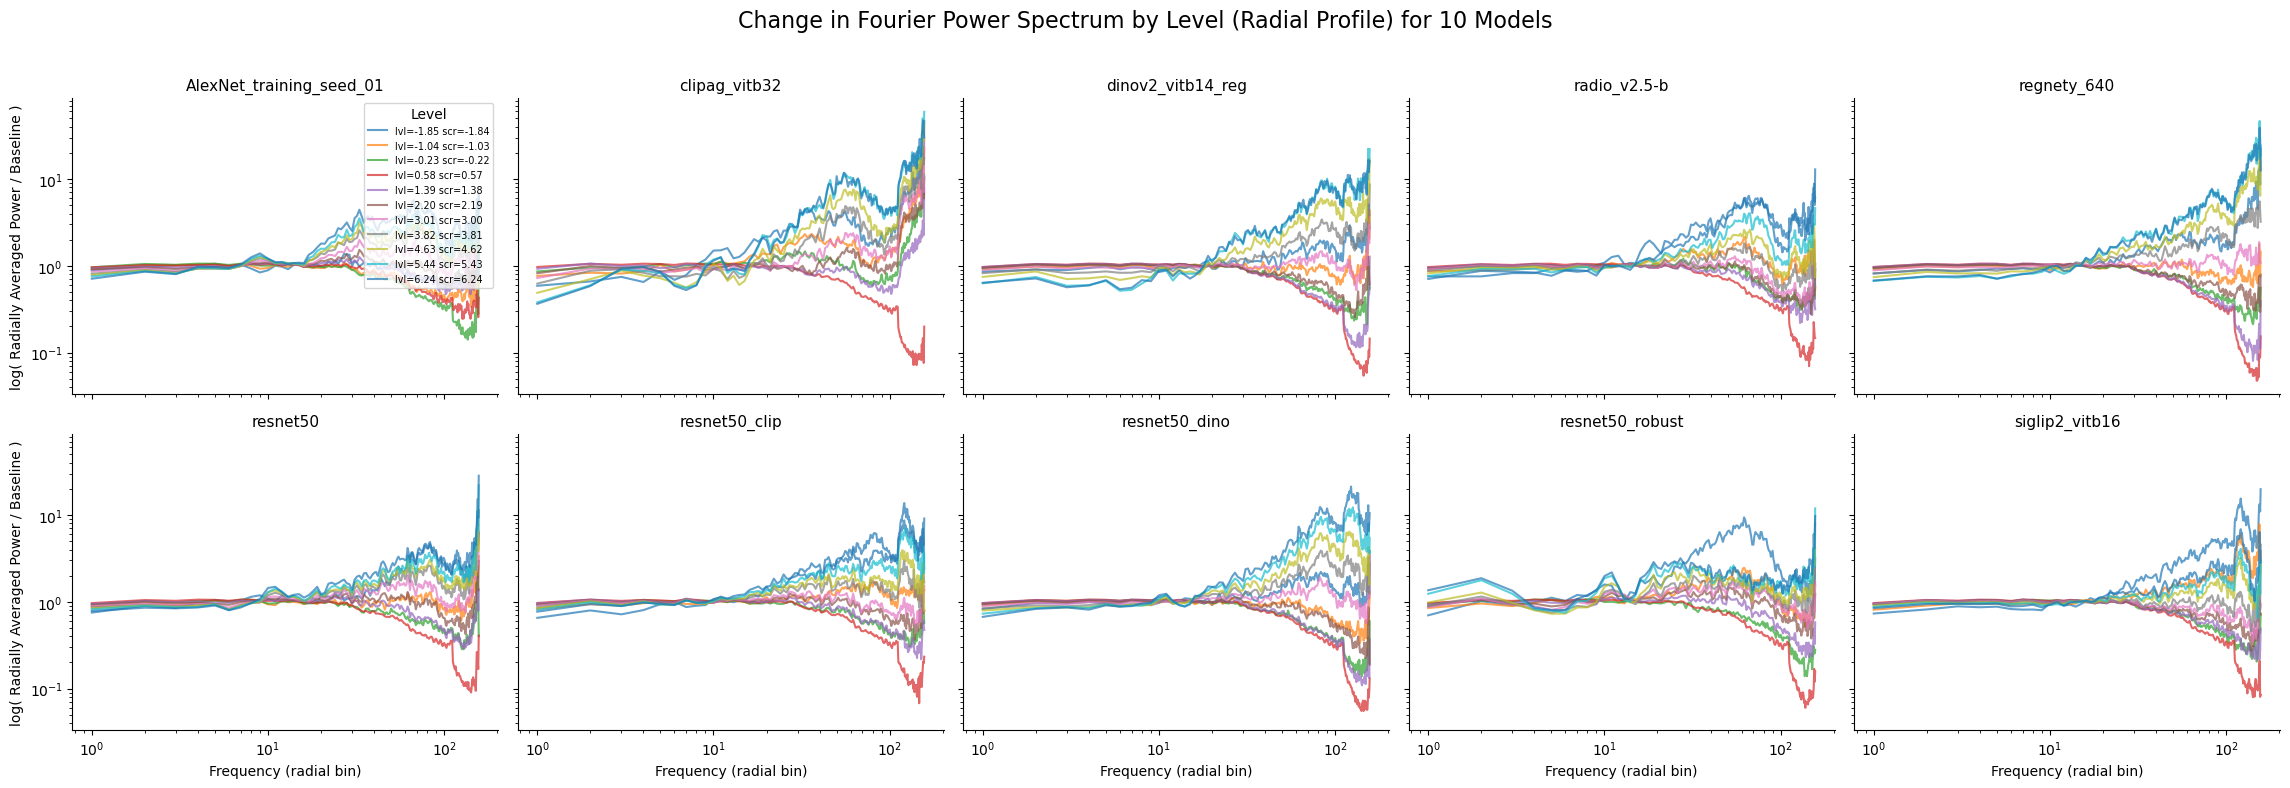

In [64]:
import matplotlib.pyplot as plt
# Choose 10 unique model names (make sure df_acc contains at least 10, otherwise adjust)
model_names = df_acc["model_name"].unique()[:10]
unit_id = 0
seed_img_id = 1
# seed_resolution = (425, 425)
seed_arr = seed_images_np[seed_img_id]
_, power_shift = image_fourier_power(seed_arr, return_shifted_spectrum=True)
prof_baseline = fourier_power_radial_profile(power_shift)

fig, axes = plt.subplots(2, 5, figsize=(23, 8), sharex=True, sharey=True)
axes = axes.flatten()
for ax, model_name in zip(axes, model_names):
    df_acc_part = df_acc.query("unit_id == @unit_id and img_id == @seed_img_id and model_name == @model_name")
    # Sort by level
    df_sorted = df_acc_part.sort_values(by="level")
    levels_sorted = df_sorted['level'].values
    scores_sorted = df_sorted['score'].values
    filepaths_sorted = df_sorted['filepath'].values

    spectra_profiles = []
    for path in filepaths_sorted:
        arr = path_to_nparray(path, resolution=(224, 224))
        _, power_shift = image_fourier_power(arr, return_shifted_spectrum=True)
        profile = fourier_power_radial_profile(power_shift)
        spectra_profiles.append(profile)
    spectra_profiles = np.stack(spectra_profiles, axis=0)
    freqs = np.arange(spectra_profiles.shape[1])
    
    for i, (level, prof) in enumerate(zip(levels_sorted, spectra_profiles)):
        ax.plot(freqs[freqs>0], prof[freqs>0] / prof_baseline[freqs>0], label=f"lvl={level:.2f} scr={scores_sorted[i]:.2f}", alpha=0.7)
        mid_bin = len(freqs) // 3
        ax.annotate(f"{level:.2f}",
                    (freqs[mid_bin], prof[mid_bin]),
                    textcoords="offset points",
                    xytext=(0, 5), ha='center', fontsize=7)
    ax.set_title(f"{model_name}", fontsize=11)
    ax.set_yscale('log')
    ax.set_xscale('log')
    # Matplotlib does not provide is_last_row or is_first_col for Axes, so we must check by index
    idx = np.where(axes == ax)[0][0]
    nrows, ncols = 2, 5
    row = idx // ncols
    col = idx % ncols
    if row == nrows - 1:
        ax.set_xlabel('Frequency (radial bin)')
    if col == 0:
        ax.set_ylabel('log( Radially Averaged Power / Baseline )')
    # Only show legend for the first axis (can also omit to save space)
    if ax == axes[0]:
        ax.legend(title="Level", fontsize='x-small', loc='upper right')

fig.suptitle('Change in Fourier Power Spectrum by Level (Radial Profile) for 10 Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

# seed images spectra
seed_img_profiles = []
for seed_img_id in range(len(seed_images_np)):
    seed_arr = seed_images_np[seed_img_id]
    _, power_shift = image_fourier_power(seed_arr, return_shifted_spectrum=True)
    prof_baseline = fourier_power_radial_profile(power_shift)
    seed_img_profiles.append(prof_baseline)
    
# The goal: loop through df_acc row by row, compute Fourier spectrum for each image, and save as database.
spectra_db = []
for idx, row in tqdm(df_acc.iterrows()):
    model_name = row['model_name']
    unit_id = row['unit_id']
    img_id = row['img_id']
    level = row['level']
    score = row['score']
    filepath = row['filepath']

    arr = path_to_nparray(filepath, resolution=(224, 224))
    _, power_shift = image_fourier_power(arr, return_shifted_spectrum=True)
    spectrum = fourier_power_radial_profile(power_shift)
    spectrum_foldchange = spectrum / seed_img_profiles[img_id]
    spectra_db.append({
        'model_name': model_name,
        'unit_id': unit_id,
        'img_id': img_id,
        'level': level,
        'score': score,
        'filepath': filepath,
        'spectrum': spectrum,
        'spectrum_foldchange': spectrum_foldchange
    })

df_spectra = pd.DataFrame(spectra_db)

0it [00:00, ?it/s]

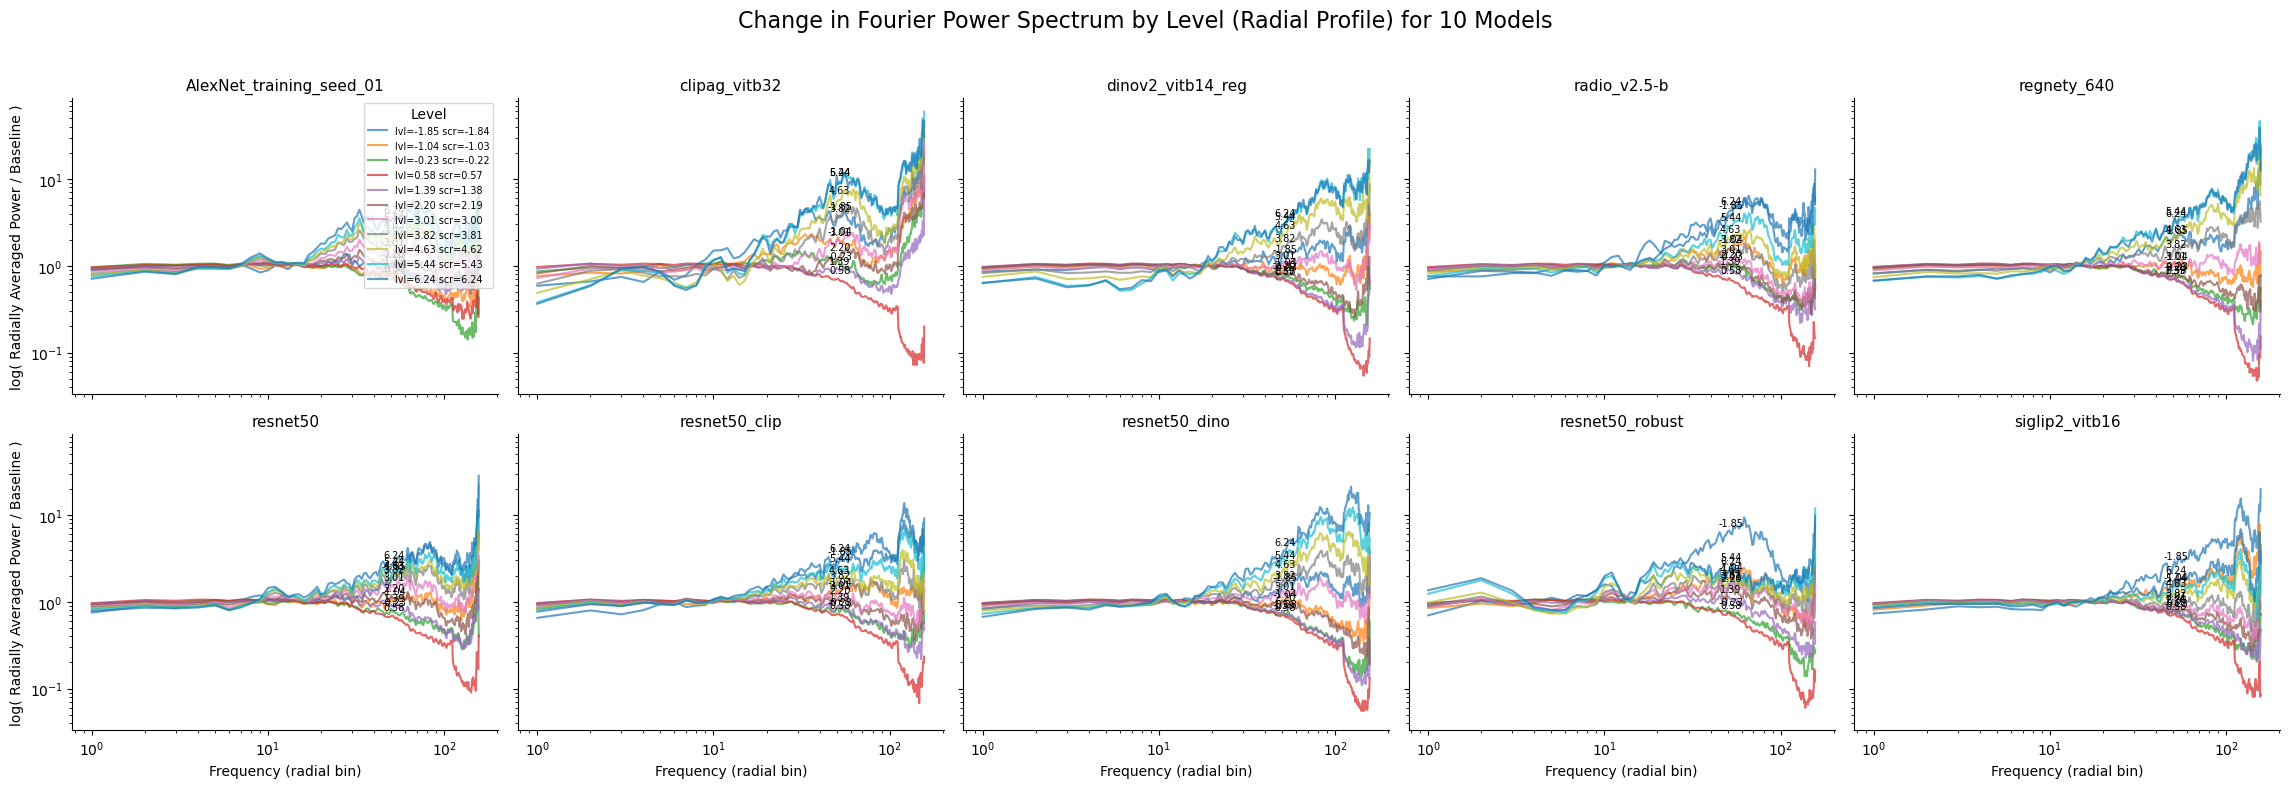

In [66]:
# Save the full dataframe for later loading/plotting
# df_spectra.to_pickle("fourier_spectra_db.pkl")  # Uncomment this line to save

# Example plotting: just as before, but now using the database
# Pick unit_id and img_id of interest for baseline, as before
unit_id_plot = 0
seed_img_id_plot = 1
model_names_plot = df_spectra["model_name"].unique()[:10]

# Compute the baseline: the spectrum of the original seed image
seed_arr = seed_images_np[seed_img_id_plot]
_, power_shift = image_fourier_power(seed_arr, return_shifted_spectrum=True)
prof_baseline = fourier_power_radial_profile(power_shift)

fig, axes = plt.subplots(2, 5, figsize=(23, 8), sharex=True, sharey=True)
axes = axes.flatten()
freqs = np.arange(df_spectra['spectrum'].iloc[0].shape[0])

for idx, model_name in enumerate(model_names_plot):
    ax = axes[idx]
    subdf = df_spectra[
        (df_spectra['model_name'] == model_name) &
        (df_spectra['unit_id'] == unit_id_plot) &
        (df_spectra['img_id'] == seed_img_id_plot)
    ].sort_values(by='level')
    if subdf.empty:
        continue
    levels_sorted = subdf['level'].values
    scores_sorted = subdf['score'].values
    spectra_profiles = np.stack(subdf['spectrum'].values, axis=0)
    spectra_profiles_norm = spectra_profiles / prof_baseline[None, :]
    for i, (level, prof) in enumerate(zip(levels_sorted, spectra_profiles_norm)):
        ax.plot(
            freqs[freqs > 0],
            prof[freqs > 0],
            label=f"lvl={level:.2f} scr={scores_sorted[i]:.2f}",
            alpha=0.7
        )
        mid_bin = len(freqs) // 3
        ax.annotate(
            f"{level:.2f}",
            (freqs[mid_bin], prof[mid_bin]),
            textcoords="offset points",
            xytext=(0, 5), ha='center', fontsize=7
        )
    ax.set_title(f"{model_name}", fontsize=11)
    ax.set_yscale('log')
    ax.set_xscale('log')
    nrows, ncols = 2, 5
    row = idx // ncols
    col = idx % ncols
    if row == nrows - 1:
        ax.set_xlabel('Frequency (radial bin)')
    if col == 0:
        ax.set_ylabel('log( Radially Averaged Power / Baseline )')
    if idx == 0:
        ax.legend(title="Level", fontsize='x-small', loc='upper right')

fig.suptitle('Change in Fourier Power Spectrum by Level (Radial Profile) for 10 Models', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [74]:
seed_arr = seed_images_np[seed_img_id_plot]
_, power_shift = image_fourier_power(seed_arr, return_shifted_spectrum=True)
prof_baseline, bin_counts = fourier_power_radial_profile_with_counts(power_shift)

In [75]:
bin_counts

array([  4,   8,  20,  20,  28,  32,  44,  52,  48,  60,  68,  64,  92,
        76, 100,  96, 100, 108, 104, 140, 132, 132, 136, 140, 172, 152,
       164, 180, 172, 184, 196, 204, 208, 204, 212, 208, 244, 244, 244,
       232, 260, 260, 264, 284, 284, 292, 280, 284, 324, 304, 324, 308,
       328, 356, 324, 356, 360, 364, 380, 344, 380, 412, 396, 400, 372,
       428, 416, 428, 428, 416, 476, 436, 460, 448, 492, 476, 456, 492,
       500, 492, 528, 492, 524, 520, 532, 532, 548, 560, 540, 564, 560,
       604, 580, 576, 604, 596, 612, 592, 620, 636, 624, 636, 644, 660,
       672, 652, 660, 648, 716, 684, 680, 724, 612, 588, 504, 484, 492,
       432, 452, 388, 404, 400, 324, 364, 320, 332, 308, 276, 296, 252,
       268, 248, 236, 220, 200, 228, 180, 188, 176, 140, 180, 128, 156,
       116, 116, 112,  84, 108,  72,  84,  60,  40,  68,  28,  44,  16,
        20,   4])

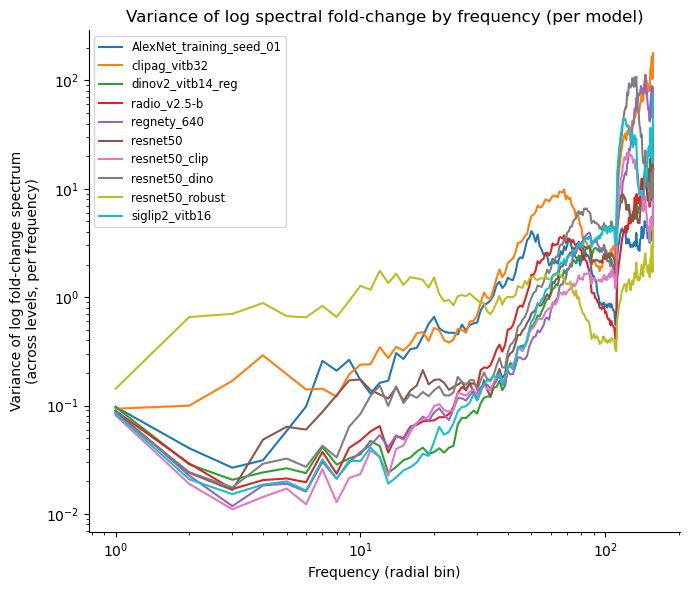

In [72]:
# For each model, compute variance of the log fold-change profile (across levels) for each frequency
# Plot: for each model, show a variance curve as a function of frequency

import numpy as np
import matplotlib.pyplot as plt

model_var_logfold_freq = {}

for model_name in model_names_plot:
    subdf = df_spectra[
        (df_spectra['model_name'] == model_name)
    ].sort_values(by='level')
    if subdf.empty:
        model_var_logfold_freq[model_name] = np.full_like(prof_baseline, np.nan, dtype=float)
        continue
    spectra_profiles = np.stack(subdf['spectrum_foldchange'].values, axis=0)
    # Compute variance across levels (axis=0 is levels, axis=1 is frequencies)
    var_log_fold_freq = np.nanvar(spectra_profiles, axis=0)
    model_var_logfold_freq[model_name] = var_log_fold_freq

freqs = np.arange(prof_baseline.shape[0])

plt.figure(figsize=(7, 6))
for model_name in model_names_plot:
    var_curve = model_var_logfold_freq[model_name]
    plt.plot(freqs[freqs > 0], var_curve[freqs > 0], label=model_name)
plt.xlabel("Frequency (radial bin)")
plt.ylabel("Variance of log fold-change spectrum\n(across levels, per frequency)")
plt.title("Variance of log spectral fold-change by frequency (per model)")
plt.yscale('log')
plt.xscale('log')
plt.legend(fontsize='small', loc='best')
plt.tight_layout()
plt.show()

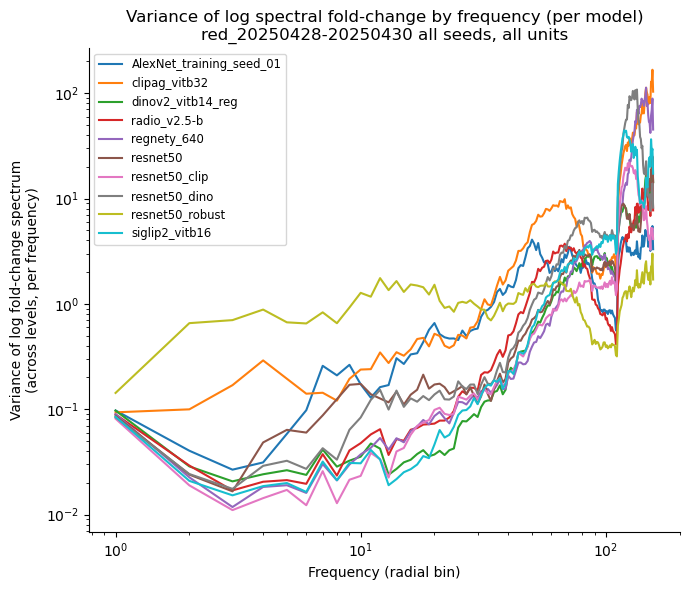

In [ ]:
# For each model, compute variance of the log fold-change profile (across levels) for each frequency
# Plot: for each model, show a variance curve as a function of frequency
import numpy as np
import matplotlib.pyplot as plt

model_var_logfold_freq = {}
for model_name in model_names_plot:
    subdf = df_spectra[
        (df_spectra['model_name'] == model_name)
    ].sort_values(by='level')
    if subdf.empty:
        model_var_logfold_freq[model_name] = np.full_like(prof_baseline, np.nan, dtype=float)
        continue
    spectra_profiles = np.stack(subdf['spectrum_foldchange'].values, axis=0)
    # Compute variance across levels (axis=0 is levels, axis=1 is frequencies)
    var_log_fold_freq = np.nanvar(spectra_profiles, axis=0)
    model_var_logfold_freq[model_name] = var_log_fold_freq

freqs = np.arange(prof_baseline.shape[0])

plt.figure(figsize=(7, 6))
for model_name in model_names_plot:
    var_curve = model_var_logfold_freq[model_name]
    plt.plot(freqs[bin_counts > 4], var_curve[bin_counts > 4], label=model_name)
plt.xlabel("Frequency (radial bin)")
plt.ylabel("Variance of log fold-change spectrum\n(across units, levels, per frequency)")
plt.title(f"Variance of log spectral fold-change by frequency (per model)\n{subject_id} all seeds, all units")
plt.yscale('log')
plt.xscale('log')
plt.legend(fontsize='small', loc='best')
plt.tight_layout()
plt.show()

### Mass compute

Processing red_20250428-20250430


0it [00:00, ?it/s]

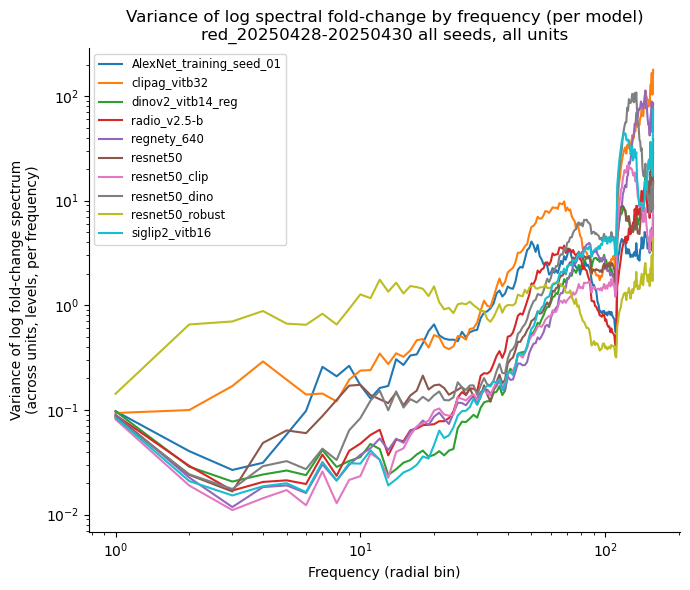

Processing venus_250426-250429


0it [00:00, ?it/s]

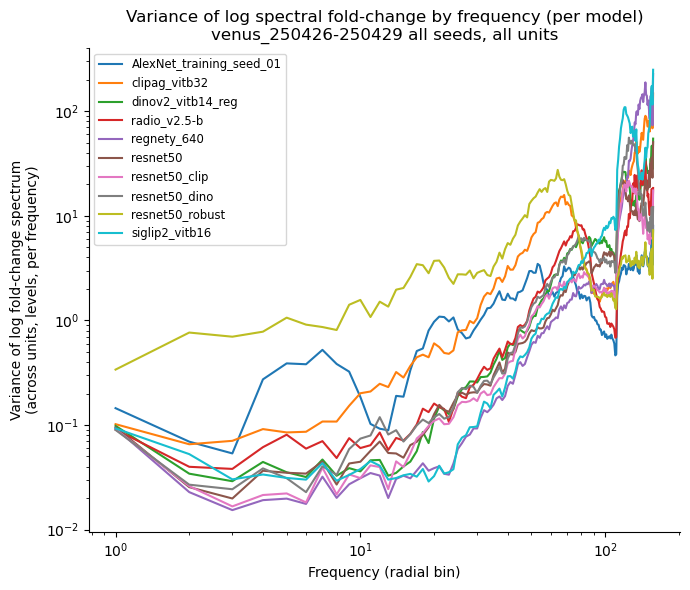

Processing three0_250426-250501


0it [00:00, ?it/s]

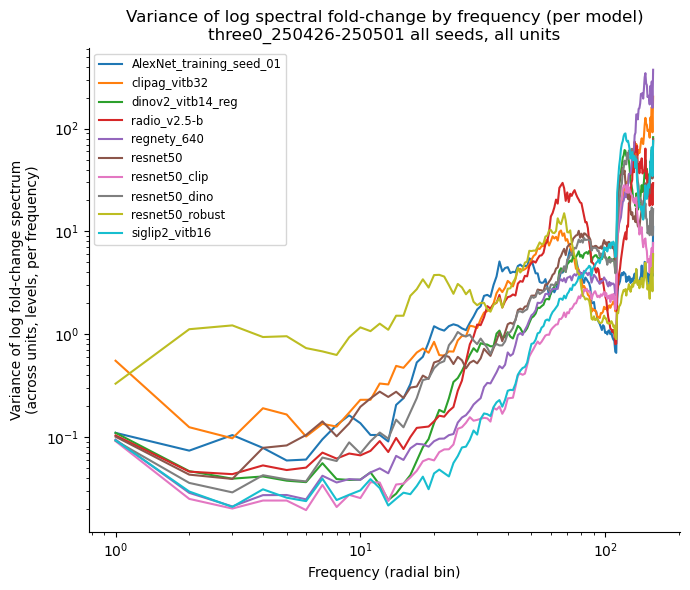

Processing paul_20250428-20250430


0it [00:00, ?it/s]

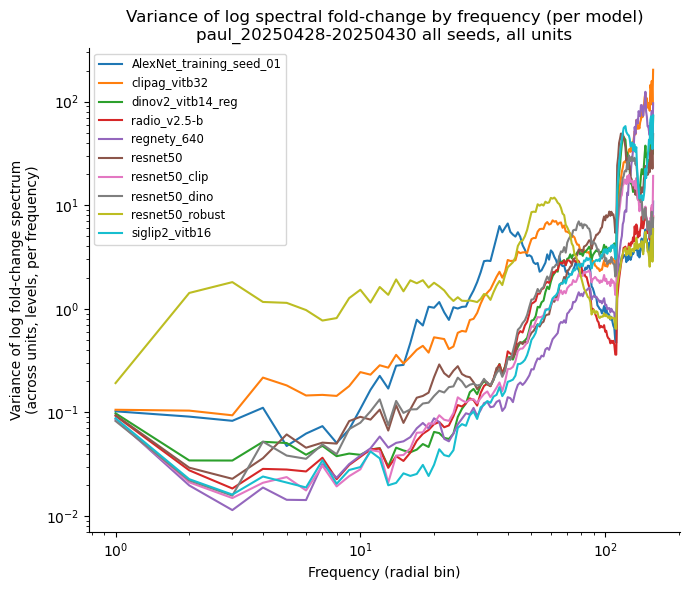

Processing leap_250426-250501


0it [00:00, ?it/s]

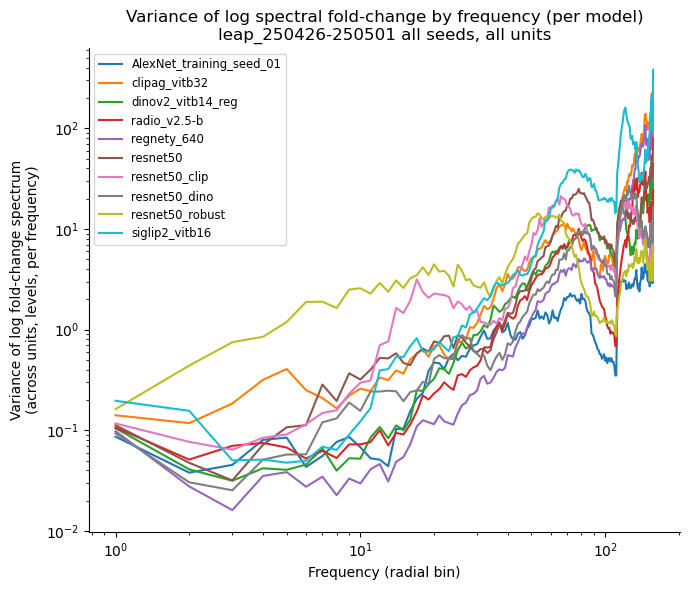

In [81]:
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl
from os.path import join
from tqdm.notebook import tqdm
from circuit_toolkit.plot_utils import saveallforms
import os
seed_image_paths = [
    "shared1000/shared0575_nsd43157.png",
    "shared1000/shared0850_nsd61798.png",
    "shared1000/shared0968_nsd70194.png",
    "shared1000/shared0241_nsd20065.png",
    "shared1000/shared0160_nsd13231.png",
    "shared1000/shared0070_nsd07008.png",
    "shared1000/shared0055_nsd05879.png",
    "shared1000/shared0668_nsd48623.png",
    "shared1000/shared0488_nsd36979.png",
    "shared1000/shared0940_nsd68312.png"
]

# Load the seed images and collect them into a list of numpy arrays
shared_dir = "/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Stimuli/"
seed_images_np = [path_to_nparray(join(shared_dir, path), resolution=(224, 224)) for path in seed_image_paths]
# seed images spectra
seed_img_profiles = []
for seed_img_id in range(len(seed_images_np)):
    seed_arr = seed_images_np[seed_img_id]
    _, power_shift = image_fourier_power(seed_arr, return_shifted_spectrum=True)
    prof_baseline = fourier_power_radial_profile(power_shift)
    seed_img_profiles.append(prof_baseline)
    
for subject_id in ['red_20250428-20250430', 'venus_250426-250429', 'three0_250426-250501', 'paul_20250428-20250430', 'leap_250426-250501']:
    print(f"Processing {subject_id}")
    subject_dir = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}"
    fft_dir = join(subject_dir, "posthoc_model_predict", "accentuated_images_fourier_spectra")
    os.makedirs(fft_dir, exist_ok=True)
    csv_path = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}/posthoc_model_predict/accentuated_stim_info_{subject_id}.csv"
    df_acc = pd.read_csv(csv_path, index_col=0)
    img_paths = df_acc["filepath"].tolist()  # absolute PNG paths like ...Accentuate_VVS/accentuation_outputs/...png

    # The goal: loop through df_acc row by row, compute Fourier spectrum for each image, and save as database.
    spectra_db = []
    for idx, row in tqdm(df_acc.iterrows()):
        model_name = row['model_name']
        unit_id = row['unit_id']
        img_id = row['img_id']
        level = row['level']
        score = row['score']
        filepath = row['filepath']

        arr = path_to_nparray(filepath, resolution=(224, 224))
        _, power_shift = image_fourier_power(arr, return_shifted_spectrum=True)
        spectrum, bin_counts = fourier_power_radial_profile_with_counts(power_shift)
        spectrum_foldchange = spectrum / seed_img_profiles[img_id]
        spectra_db.append({
            'model_name': model_name,
            'unit_id': unit_id,
            'img_id': img_id,
            'level': level,
            'score': score,
            'filepath': filepath,
            'spectrum': spectrum,
            'spectrum_foldchange': spectrum_foldchange
        })

    df_spectra = pd.DataFrame(spectra_db)
    df_spectra.to_pickle(join(fft_dir, "accentuated_images_fourier_spectra_db.pkl"))
    
    model_var_logfold_freq = {}
    for model_name in model_names_plot:
        subdf = df_spectra[
            (df_spectra['model_name'] == model_name)
        ].sort_values(by='level')
        if subdf.empty:
            model_var_logfold_freq[model_name] = np.full_like(prof_baseline, np.nan, dtype=float)
            continue
        spectra_profiles = np.stack(subdf['spectrum_foldchange'].values, axis=0)
        # Compute variance across levels (axis=0 is levels, axis=1 is frequencies)
        var_log_fold_freq = np.nanvar(spectra_profiles, axis=0)
        model_var_logfold_freq[model_name] = var_log_fold_freq

    freqs = np.arange(prof_baseline.shape[0])
    
    pkl.dump({
        "model_var_logfold_freq": model_var_logfold_freq,
        "freqs": freqs,
        "bin_counts": bin_counts,
        "prof_baseline": prof_baseline,
        "model_names_plot": model_names_plot,
    }, open(join(fft_dir, f"{subject_id}_all_seeds_all_units_freq_var_logfold.pkl"), "wb"))
    
    plt.figure(figsize=(7, 6))
    for model_name in model_names_plot:
        var_curve = model_var_logfold_freq[model_name]
        plt.plot(freqs[freqs > 0], var_curve[freqs > 0], label=model_name)
    plt.xlabel("Frequency (radial bin)")
    plt.ylabel("Variance of log fold-change spectrum\n(across units, levels, per frequency)")
    plt.title(f"Variance of log spectral fold-change by frequency (per model)\n{subject_id} all seeds, all units")
    plt.yscale('log')
    plt.xscale('log')
    plt.legend(fontsize='small', loc='best')
    plt.tight_layout()
    saveallforms(fft_dir, f"{subject_id}_all_seeds_all_units_freq_var_logfold")
    plt.show()  

### Read the spectrum files

In [ ]:
import pandas as pd
from os.path import join
# for subject_id in ['red_20250428-20250430', 'venus_250426-250429', 'three0_250426-250501', 'paul_20250428-20250430', 'leap_250426-250501']:
subject_id = 'red_20250428-20250430'
subject_dir = f"/n/holylabs/LABS/alvarez_lab/Lab/VVS_Accentuation/Encoding_models/{subject_id}"
fft_dir = join(subject_dir, "posthoc_model_predict", "accentuated_images_fourier_spectra")
df_spectra = pd.read_pickle(join(fft_dir, "accentuated_images_fourier_spectra_db.pkl"))
print(df_spectra.head())  # Show a preview

                 model_name  unit_id  img_id     level     score  \
0  AlexNet_training_seed_01        0       0 -0.228237 -0.221289   
1  AlexNet_training_seed_01        0       0 -1.037346 -1.027856   
2  AlexNet_training_seed_01        0       0 -1.846455 -1.838532   
3  AlexNet_training_seed_01        0       0  0.580873  0.572135   
4  AlexNet_training_seed_01        0       0  1.389982  1.380919   

                                            filepath  \
0  /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...   
1  /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...   
2  /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...   
3  /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...   
4  /n/holylabs/LABS/alvarez_lab/Everyone/Accentua...   

                                            spectrum  \
0  [140169703.141892, 447336.1776671389, 111919.7...   
1  [139148682.66720036, 433592.1596170982, 113652...   
2  [138562352.8977393, 429475.28034083056, 114240...   
3  [140922891.88068712, 448598